# 1.2 Preprocessing — Full-Stack Test (510 planes)

Background removal (rolling ball) and PSF-centered Richardson-Lucy deconvolution are computed
in `1_1_preprocessing.ipynb`. This notebook **reads those saved full-stack outputs** and QCs
them against `zone_samples.csv`, which defines representative depth zones across the stack.

Two separate checks:
- **Data-integrity check** (Section 3): whole-plane mean at each `sample_plane` vs. the
  `sample_plane_intensity` recorded in `zone_samples.csv`, confirming the loaded raw stack
  matches the one the reference values were built from.
- **Signal QC** (Sections 5, 7): a **normalized foreground mean** per stage — the mean over
  the Otsu-thresholded foreground (connexin signal), with each stage scaled to its own
  99.5th-percentile intensity so the three stages are on a common, dimensionless scale.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import threshold_otsu

BASE_DIR = Path.cwd().parent

## 0. Load zone samples

Adjust `zone_samples_path` below if your file lives somewhere else.

In [2]:
zone_samples_path = BASE_DIR / 'data' / 'zone_samples.csv'
zone_samples = pd.read_csv(zone_samples_path)
print(f"Loaded {len(zone_samples)} zones from {zone_samples_path}")
zone_samples


Loaded 9 zones from /home/rck292/Project/data/zone_samples.csv


,zone_number,zone_label,z_start,z_end,sample_plane,sample_plane_intensity
0,1,plateau,0,34,17,236.49
1,2,rising-1,34,101,67,515.66
2,3,rising-2,101,169,135,2222.98
3,4,rising-3,169,236,202,5335.92
4,5,rising-4,236,304,270,9162.24
5,6,rising-5,304,372,338,11514.37
6,7,falling-1,372,417,394,11384.69
7,8,falling-2,417,463,440,9689.39
8,9,falling-3,463,509,486,7286.28


## 1. Load the raw image stack

Used as the "before" reference for QC comparisons.

In [3]:
cnx_path = BASE_DIR / 'data' / 'raw' / 'corrected_images' / 'cnx43.tif'
cnx_img = io.imread(cnx_path)
print(f"Loaded stack: shape={cnx_img.shape}, dtype={cnx_img.dtype}")

# remove black border on top (matches convention in 1_1_preprocessing.ipynb)
cnx_img = cnx_img[:, 15:, :]
print(f"After border crop: shape={cnx_img.shape}")

n_planes = cnx_img.shape[0]

out_of_range = zone_samples[~zone_samples['sample_plane'].between(0, n_planes - 1)]
if len(out_of_range):
    print("WARNING: sample planes out of range for this stack:")
    print(out_of_range)
else:
    print("All zone_samples.sample_plane values are within the stack range.")


Loaded stack: shape=(510, 2048, 1012), dtype=uint16
After border crop: shape=(510, 2033, 1012)
All zone_samples.sample_plane values are within the stack range.


## 2. QC helpers

In [ ]:
def plot_zone_grid(stack, zone_df, title, cmap='gray', ncols=4, vmax_percentile=99.5):
    """One subplot per zone, showing that zone's sample_plane."""
    n = len(zone_df)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
    for i, (_, row) in enumerate(zone_df.iterrows()):
        ax = axes[i // ncols, i % ncols]
        plane = int(row['sample_plane'])
        vmax = np.percentile(stack[plane], vmax_percentile)
        ax.imshow(stack[plane], cmap=cmap, vmax=vmax)
        ax.set_title(f"{row['zone_label']} (plane {plane})")
        ax.axis('off')
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def zone_intensity_table(stack, zone_df, column_name):
    """Whole-plane mean at each zone's sample_plane (used only for the data-integrity
    check against the recorded sample_plane_intensity)."""
    values = [stack[int(row['sample_plane'])].mean() for _, row in zone_df.iterrows()]
    return pd.DataFrame({
        'zone_number': zone_df['zone_number'].values,
        column_name: values,
    })


def robust_max(stack, pmax=99.5, subsample=20):
    """Robust maximum (pmax-th percentile) from a strided voxel subsample. Used to scale a
    stage to a dimensionless [0, 1] range so stages with different native units (uint16
    counts vs. float32 deconvolution output) become comparable."""
    flat = np.asarray(stack).ravel()[::subsample]
    hi = float(np.percentile(flat, pmax))
    return hi if hi > 0 else 1.0


def foreground_mean(plane):
    """Mean intensity over the Otsu-thresholded foreground of a single plane. Isolates the
    connexin signal from empty/background pixels; a whole-plane mean is dominated by
    background, especially after rolling-ball subtraction zeroes most of the field."""
    p = np.asarray(plane, dtype=np.float32)
    finite = p[np.isfinite(p)]
    if finite.size == 0 or np.ptp(finite) == 0:
        return np.nan
    thr = threshold_otsu(finite)
    fg = p >= thr
    if not fg.any():
        return np.nan
    return float(p[fg].mean())


def zone_foreground_table(stack, zone_df, column_name, norm):
    """Per-zone normalized foreground mean at each sample_plane. Each plane is divided by
    `norm` (the stage's robust_max) so values are a dimensionless fraction of the stage's
    dynamic range and directly comparable across stages/zones."""
    values = []
    for _, row in zone_df.iterrows():
        plane = np.asarray(stack[int(row['sample_plane'])], dtype=np.float32) / norm
        values.append(foreground_mean(plane))
    return pd.DataFrame({
        'zone_number': zone_df['zone_number'].values,
        column_name: values,
    })

## 3. Raw-stack QC (data-integrity check)

Whole-plane mean at each `sample_plane` vs. the recorded `sample_plane_intensity`. This is a
data-integrity check — a small, consistent offset is expected if the 15-row border crop here
was not applied when the reference values were originally recorded.

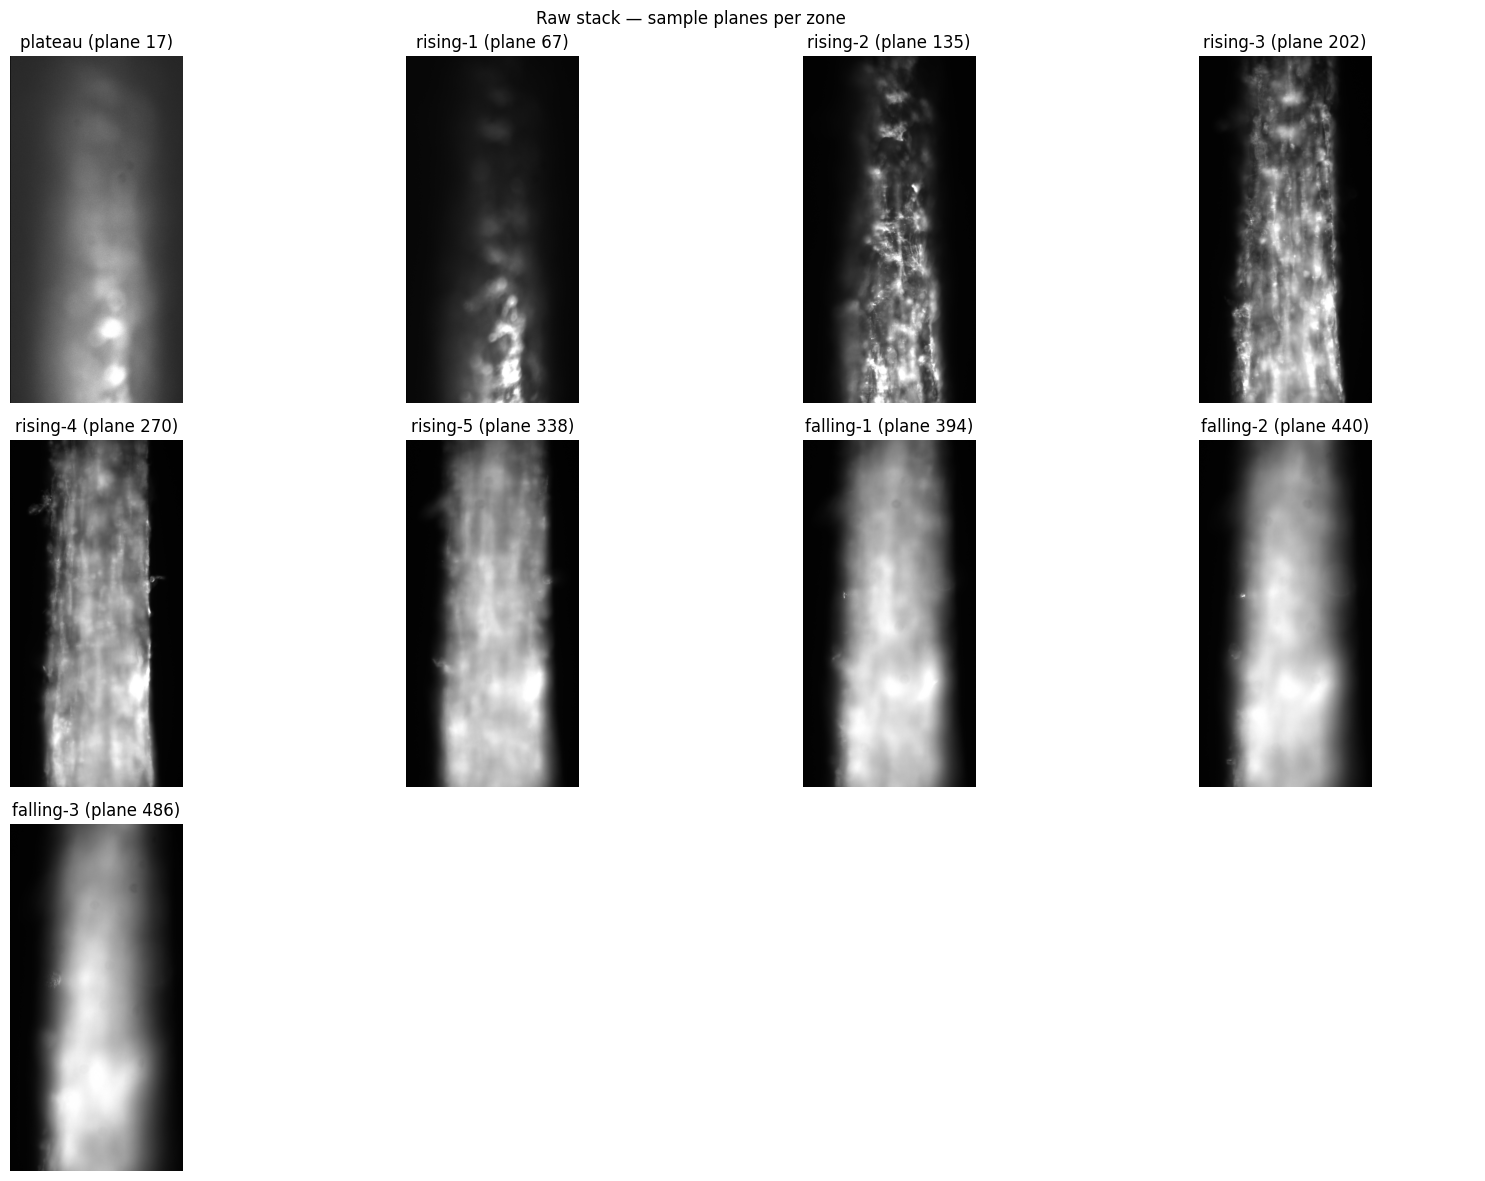

Recorded vs. computed intensity at each zone's sample plane (raw stack):


,zone_number,zone_label,sample_plane,sample_plane_intensity,computed_intensity_raw,diff,pct_diff
0,1,plateau,17,236.49,238.230797,1.740797,0.736098
1,2,rising-1,67,515.66,519.467567,3.807567,0.738387
2,3,rising-2,135,2222.98,2239.383478,16.403478,0.737905
3,4,rising-3,202,5335.92,5375.286092,39.366092,0.737756
4,5,rising-4,270,9162.24,9229.836723,67.596723,0.737775
5,6,rising-5,338,11514.37,11599.328719,84.958719,0.737849
6,7,falling-1,394,11384.69,11468.685495,83.995495,0.737793
7,8,falling-2,440,9689.39,9760.877635,71.487635,0.737793
8,9,falling-3,486,7286.28,7340.042986,53.762986,0.737866


In [5]:
plot_zone_grid(cnx_img, zone_samples, title="Raw stack — sample planes per zone")

raw_intensity = zone_intensity_table(cnx_img, zone_samples, 'computed_intensity_raw')
raw_comparison = zone_samples[['zone_number', 'zone_label', 'sample_plane', 'sample_plane_intensity']].merge(
    raw_intensity, on='zone_number'
)
raw_comparison['diff'] = raw_comparison['computed_intensity_raw'] - raw_comparison['sample_plane_intensity']
raw_comparison['pct_diff'] = 100 * raw_comparison['diff'] / raw_comparison['sample_plane_intensity']
print("Recorded vs. computed intensity at each zone's sample plane (raw stack):")
raw_comparison


## 4. Load background-removed image

Loads the rolling-ball background-subtracted stack saved by `1_1_preprocessing.ipynb`.
Path is relative to the `notebooks/` working directory, matching how it was saved.

In [ ]:
bg_removed_path = BASE_DIR / 'data' / 'preprocessed' / 'background_removed_img.tiff'
background_removed = io.imread(bg_removed_path)
print(f"Loaded background-removed stack: shape={background_removed.shape}, dtype={background_removed.dtype}")
print(f"  from {bg_removed_path.resolve()}")

if background_removed.shape != cnx_img.shape:
    print(f"WARNING: shape mismatch vs. raw stack {cnx_img.shape}")

## 5. QC of background removal

In [ ]:
plot_zone_grid(background_removed, zone_samples, title="Background-removed stack — sample planes per zone")

raw_norm = robust_max(cnx_img)
bg_norm = robust_max(background_removed)
fg_raw = zone_foreground_table(cnx_img, zone_samples, 'fg_mean_raw', norm=raw_norm)
fg_bg = zone_foreground_table(background_removed, zone_samples, 'fg_mean_bg_removed', norm=bg_norm)

bg_comparison = (
    zone_samples[['zone_number', 'zone_label', 'sample_plane']]
    .merge(fg_raw, on='zone_number')
    .merge(fg_bg, on='zone_number')
)
print("Normalized foreground (connexin-signal) mean, raw vs. background-removed:")
bg_comparison[['zone_label', 'sample_plane', 'fg_mean_raw', 'fg_mean_bg_removed']]

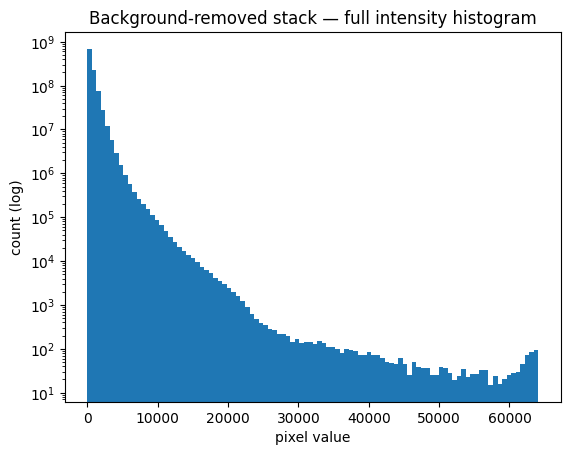

min=0, max=64068


In [8]:
plt.hist(background_removed.ravel(), bins=100)
plt.yscale('log')
plt.xlabel('pixel value')
plt.ylabel('count (log)')
plt.title('Background-removed stack — full intensity histogram')
plt.show()
print(f"min={background_removed.min()}, max={background_removed.max()}")


## 6. Load deconvolved image

Loads the PSF-centered Richardson-Lucy deconvolution output saved by
`1_1_preprocessing.ipynb`.

In [ ]:
deconvolved_path = BASE_DIR / 'data' / 'preprocessed' / 'background_removed_and_deconvolved_img.tiff'
deconvolved = io.imread(deconvolved_path)
print(f"Loaded deconvolved stack: shape={deconvolved.shape}, dtype={deconvolved.dtype}")
print(f"  from {deconvolved_path.resolve()}")

if deconvolved.shape != cnx_img.shape:
    print(f"WARNING: shape mismatch vs. raw stack {cnx_img.shape}")

## 7. Final QC — raw vs. background-removed vs. deconvolved

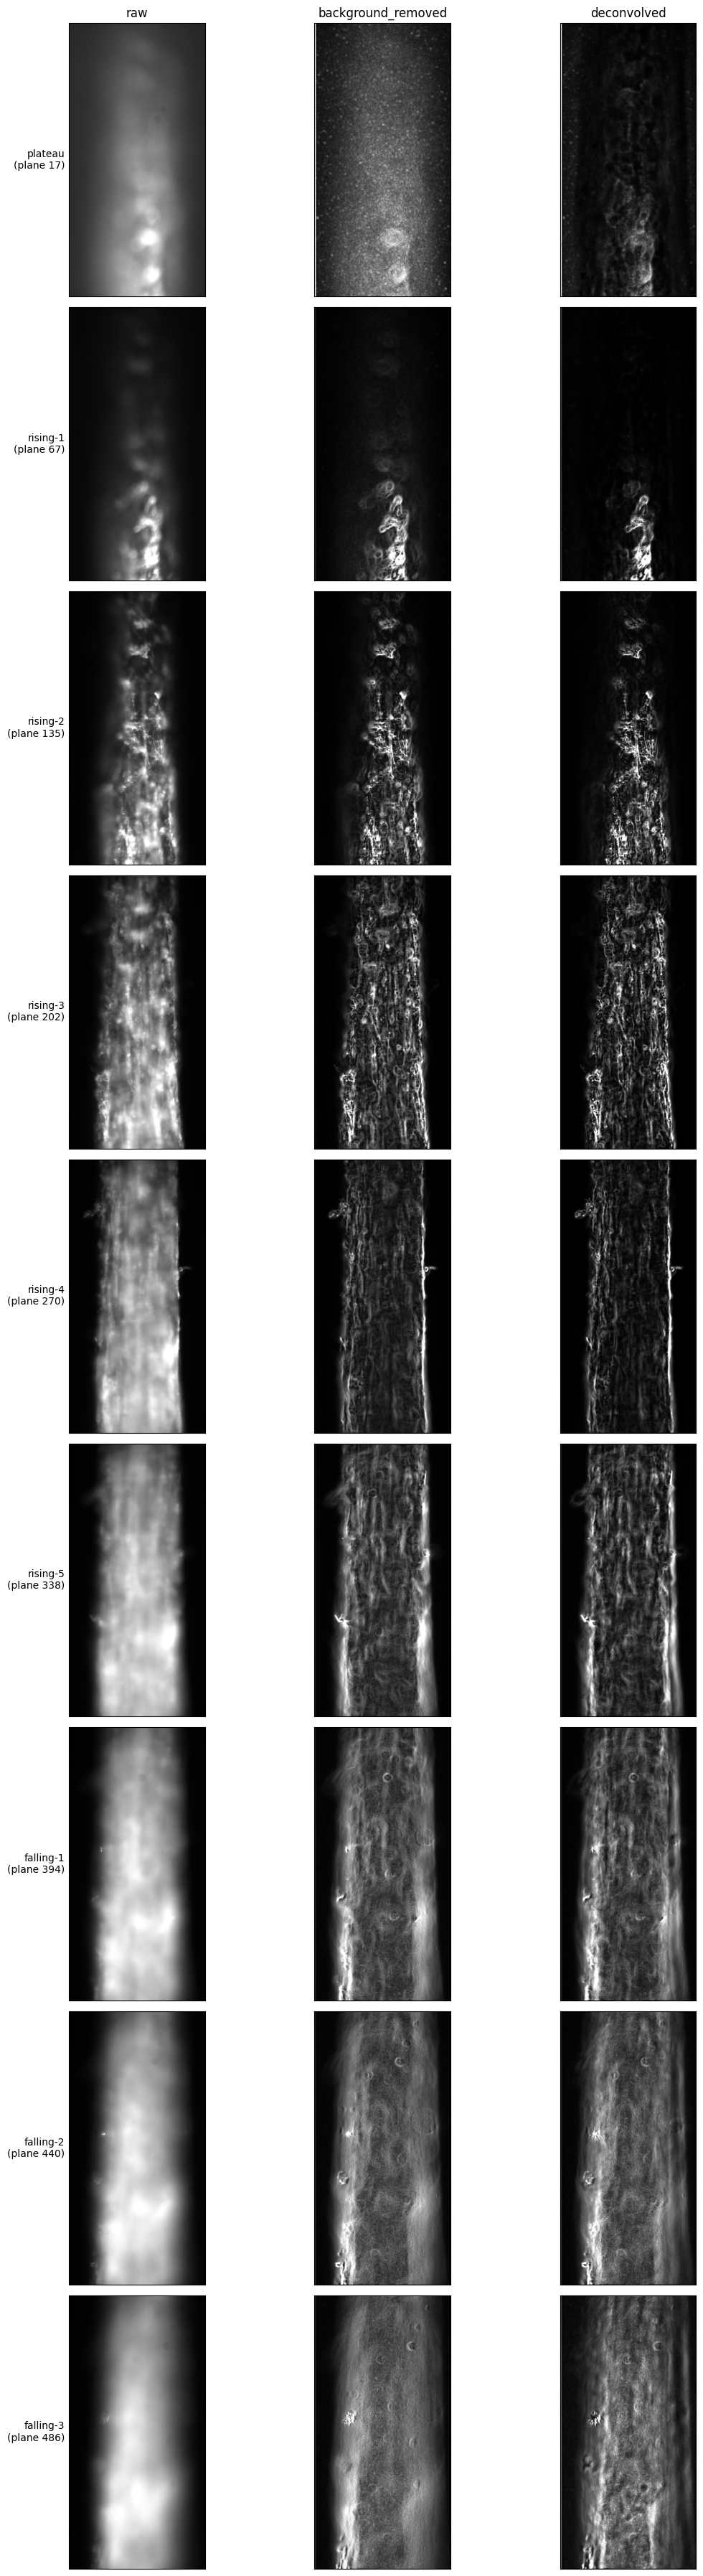

In [11]:
def plot_zone_stage_grid(stages, zone_df, cmap='gray', vmax_percentile=99.5):
    """Grid of (zone rows) x (pipeline stage columns) at each zone's sample_plane."""
    n_zones = len(zone_df)
    n_stages = len(stages)
    fig, axes = plt.subplots(n_zones, n_stages, figsize=(4 * n_stages, 4 * n_zones), squeeze=False)
    for i, (_, row) in enumerate(zone_df.iterrows()):
        plane = int(row['sample_plane'])
        for j, (stage_name, stage_stack) in enumerate(stages.items()):
            ax = axes[i, j]
            vmax = np.percentile(stage_stack[plane], vmax_percentile)
            ax.imshow(stage_stack[plane], cmap=cmap, vmax=vmax)
            if i == 0:
                ax.set_title(stage_name)
            if j == 0:
                ax.set_ylabel(f"{row['zone_label']}\n(plane {plane})", rotation=0, ha='right', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
    plt.tight_layout()
    plt.show()

stages = {
    'raw': cnx_img,
    'background_removed': background_removed,
    'deconvolved': deconvolved,
}
plot_zone_stage_grid(stages, zone_samples)


In [ ]:
raw_norm = robust_max(cnx_img)
bg_norm = robust_max(background_removed)
deconv_norm = robust_max(deconvolved)
print("Per-stage normalization factors (99.5th-percentile intensity):")
print(f"  raw={raw_norm:.1f}, background_removed={bg_norm:.1f}, deconvolved={deconv_norm:.4f}")

fg_raw = zone_foreground_table(cnx_img, zone_samples, 'fg_mean_raw', norm=raw_norm)
fg_bg = zone_foreground_table(background_removed, zone_samples, 'fg_mean_bg_removed', norm=bg_norm)
fg_dc = zone_foreground_table(deconvolved, zone_samples, 'fg_mean_deconvolved', norm=deconv_norm)

final_summary = zone_samples[['zone_number', 'zone_label', 'sample_plane']].copy()
for t in (fg_raw, fg_bg, fg_dc):
    final_summary = final_summary.merge(t, on='zone_number')

print()
print("Normalized foreground mean per stage")
print("(dimensionless, fraction of each stage's 99.5th-percentile intensity; comparable across stages/zones):")
final_summary

In [ ]:
# Full intensity distribution per stage (subsampled for speed)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, stack) in zip(
    axes,
    [('raw', cnx_img), ('background_removed', background_removed), ('deconvolved', deconvolved)],
):
    ax.hist(stack.ravel()[::20], bins=100)
    ax.set_yscale('log')
    ax.set_xlabel('pixel value')
    ax.set_ylabel('count (log)')
    ax.set_title(name)
fig.suptitle('Full intensity distribution per stage')
plt.tight_layout()
plt.show()

## Summary

This notebook reads and QCs the full-stack outputs from `1_1_preprocessing.ipynb`; it does not
recompute background removal or deconvolution.

- **Section 3** validates the loaded raw stack against the recorded `sample_plane_intensity`
  (whole-plane mean — a data-integrity check, not a signal measure).
- **Sections 5 and 7** use the **normalized foreground mean**: mean over the Otsu-thresholded
  foreground of each sample plane, with every stage scaled to its own 99.5th-percentile
  intensity. This isolates connexin signal from background and puts raw, background-removed,
  and deconvolved stages on one dimensionless scale.

**Interpretation caveat:** because each stage is normalized to its own dynamic range, the
foreground means are comparable *across stages and zones* but are not absolute intensities.
Richardson-Lucy output in particular is not in the same physical units as the raw counts, so
only the normalized values should be compared — never the raw magnitudes.